Import functions and download data

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import numpy as np
import sys
import os
sys.path.append(os.path.abspath("C:/Users/mqsim/jupyter_projects/code"))
from utils2 import download_data
import lfp_functions as lf

# sns.set_theme(context='notebook',style='white',font_scale=1.5,
#               rc = {'axes.spines.top':False,'axes.spines.right':False,
#                      'image.cmap':plt.cm.jet})

sns.set_theme(context='notebook',style='white',font_scale=1.5,
               rc = {'axes.spines.top':False,'axes.spines.right':False})

ModuleNotFoundError: No module named 'utils2'

In [ ]:
# Download lesson data
download_data('https://surfdrive.surf.nl/files/index.php/s/9nY01qMimFLez40')

---------------------------------------------------------------------------------------------------------------------------

Extract data from datafile, divide lfp data into frequency bands, plot each lfp signal against time per waveband and compute&plot power of each waveband in the lfp signal

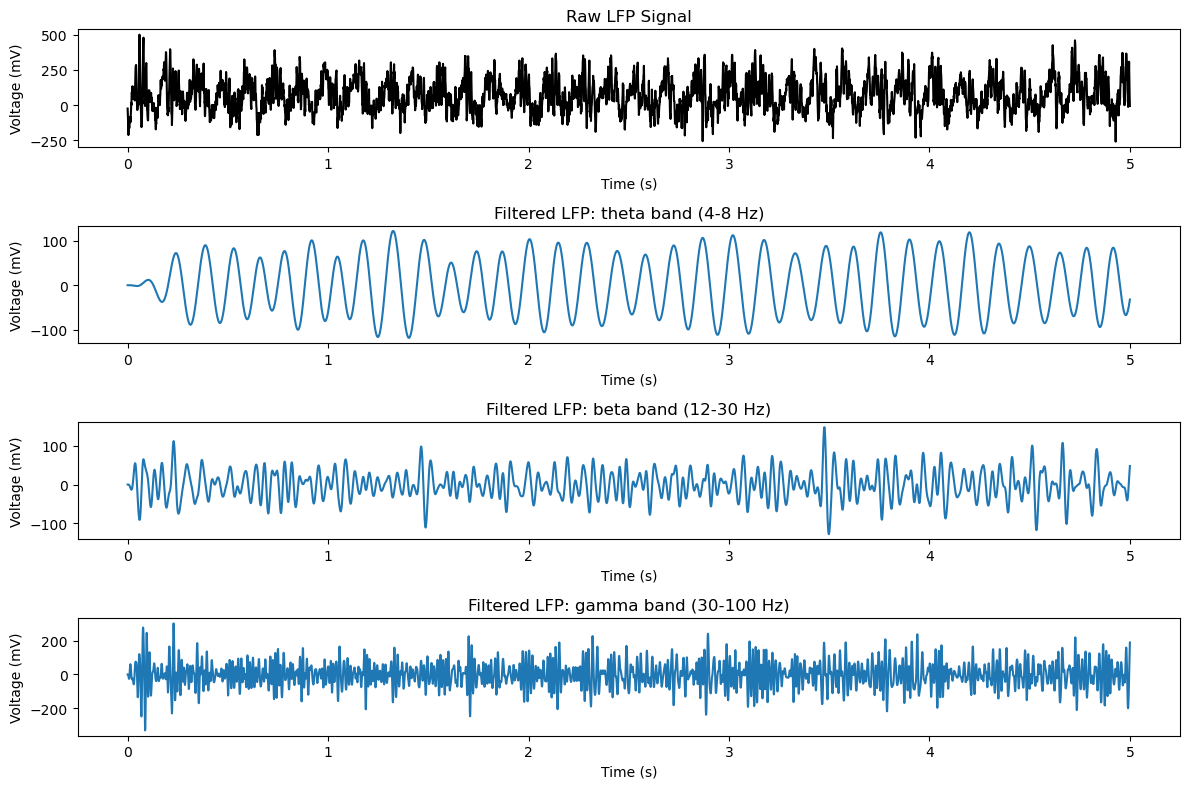

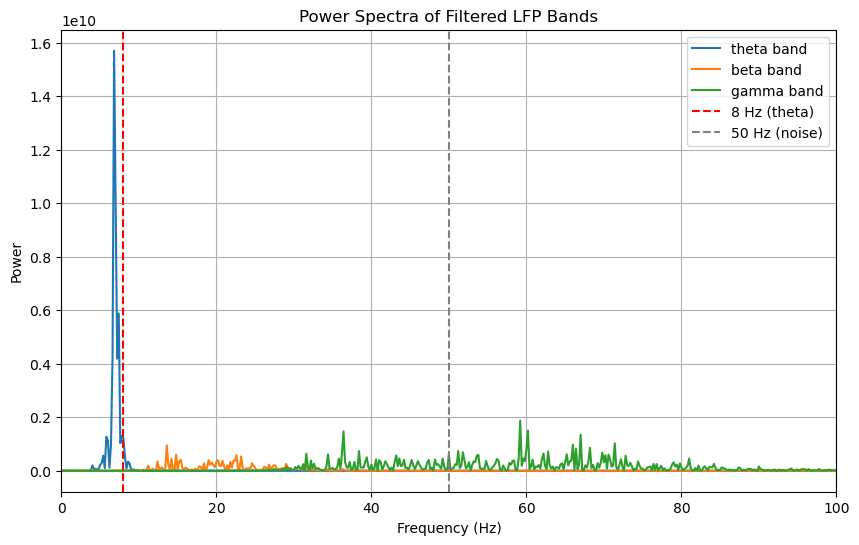

In [18]:
## Exercise 1.1
# Extract data from datafile
# Divide lfp data into frequency bands
# Plot each lfp signal against time per waveband
# Compute and plot power of each waveband in the lfp signal
##

from scipy import signal
from scipy.fft import fft, fftfreq

with open('data/moving_lfp.pickle', 'rb') as handle:
    lfp_data = pickle.load(handle)

lfp = lfp_data['lfp']
sampling_rate = lfp_data['sampling_rate']

# Select data
duration = 5 # seconds
n_samples = int(duration * sampling_rate)
time = np.linspace(0, duration, n_samples) # 0-5 seconds in between n_samples steps
lfp_segment = lfp[:n_samples]

# Frequency bands
freq_bands = {
    'theta': (4, 8),
    #'alpha': (8, 12),
    'beta': (12, 30),
    'gamma': (30, 100)
    # 'delta': (0.5, 4)
} # i guess delta and alpha is not really necessary here, but i included them for completeness, might delete later lol

# Create empty signal and power spectral densities (to compare the contents per frequency band) 
filtered_signals = {}
filtered_psds = {}

# Create filter
for band_name, (low, high) in freq_bands.items():
    sos = signal.butter(
        N = 4,
        Wn = [low, high],
        btype = 'bandpass',
        fs = sampling_rate,
        output= 'sos'
    )
    # Apply sos filter to lfp segment
    filtered = signal.sosfilt(sos, lfp_segment)
    filtered_signals[band_name] = filtered

    # Compute FFT for the filtered signal
    centered_filtered = filtered - np.mean(filtered)
    transformed = fft(centered_filtered)
    freqs = fftfreq(n_samples, 1./sampling_rate)
    transformed = transformed[:n_samples//2]
    freqs = freqs[:n_samples//2]
    power = np.abs(transformed)**2
    filtered_psds[band_name] = (freqs, power)

# Plot filtered signals (time domain)
plt.figure(figsize=(12, 8))
plt.subplot(len(freq_bands) + 1, 1, 1)
plt.plot(time, lfp_segment, label='Raw LFP', color='black')
plt.title('Raw LFP Signal')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')

# return band_name-filtered signal pair with filtered_signals.items()
for i, (band_name, filtered) in enumerate(filtered_signals.items(), start=2):
    plt.subplot(len(freq_bands) + 1, 1, i)
    plt.plot(time, filtered, label=f'Filtered ({band_name})')
    plt.title(f'Filtered LFP: {band_name} band ({freq_bands[band_name][0]}-{freq_bands[band_name][1]} Hz)')
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage (mV)')

plt.tight_layout()
plt.show()

# Power spectrum out of curiosity
plt.figure(figsize=(10, 6))
for band_name, (freqs, power) in filtered_psds.items():
    plt.plot(freqs, power, label=f'{band_name} band')
plt.xlim([0, 100])
plt.axvline(x=8, c='r', linestyle='--', label='8 Hz (theta)')
plt.axvline(x=50, c='grey', linestyle='--', label='50 Hz (noise)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('Power Spectra of Filtered LFP Bands')
plt.legend()
plt.grid(True)
plt.show()



-------------------------------------------------------------------------------------------------------------------------------

Plot all voltage-time plots with varying bandwidths and a fixed central frequency

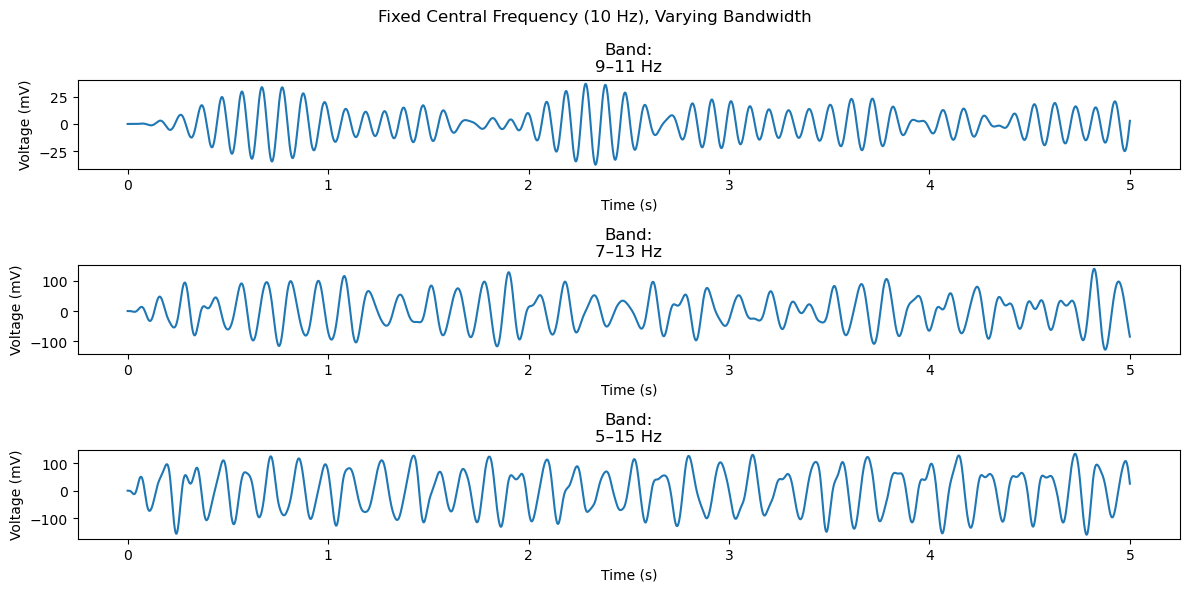

In [53]:
## Exercise 1.2
# Fix central frequency, vary bandwidth
##

central_freq = 10  
bandwidths = {
    'narrow_band': 1,
    'medium_band': 3,
    'broad_band': 5,
}   

plt.figure(figsize=(12, 6))
for i, (name, bw) in enumerate(bandwidths.items(), 1):
    low, high = central_freq - bw, central_freq + bw
    
    sos = signal.butter(N=4, Wn=[low, high], btype='bandpass', fs=sampling_rate, output='sos')
    filtered = signal.sosfilt(sos, lfp_segment)

    # Plot
    plt.subplot(3, 1, i)
    plt.plot(time, filtered)
    plt.title(f'Band:\n{low}–{high} Hz')
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage (mV)')

plt.suptitle(f'Fixed Central Frequency ({central_freq} Hz), Varying Bandwidth')
plt.tight_layout()
plt.show()


Exercise 1.2 comment: the narrower the bandwidth, the closer the signal is to the central frequency, the cleaner the signal seems, potentially filtering out more noise. the broader the bandwidth, more activity seems to be captured (evident from the not very smooth pieces in the signal), but this could also be noise.

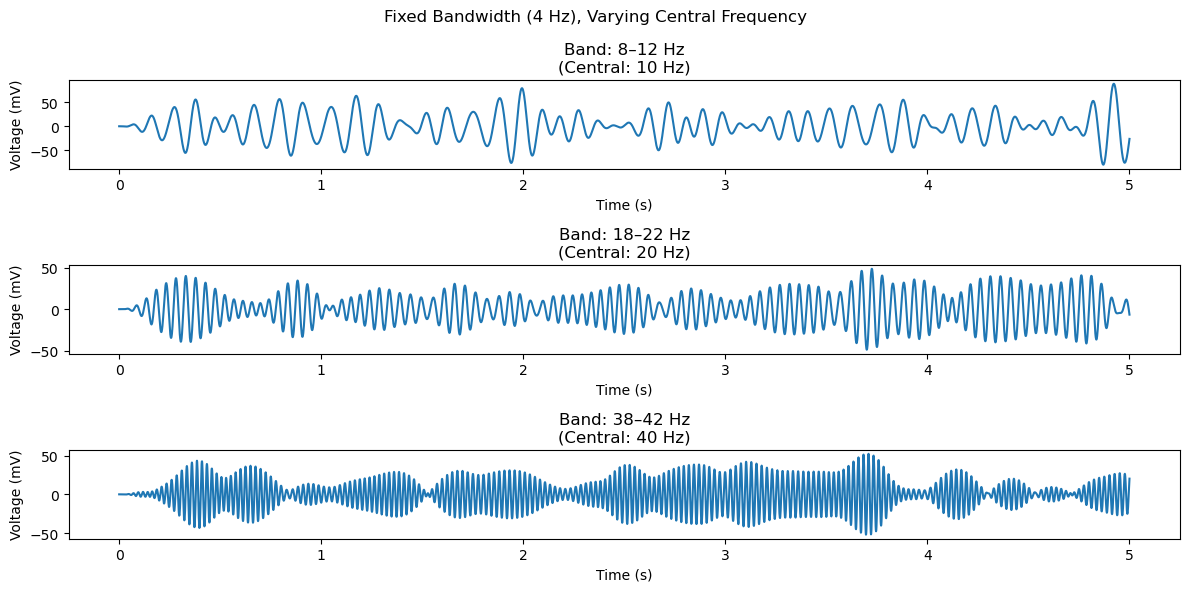

In [27]:
## Exercise 1.3
# Fix bandwidth, vary central frequency
##

bandwidth = 4  
central_freqs = [10, 20, 40]
order = [
plt.figure(figsize=(12, 6))
for i, cf in enumerate(central_freqs, 1):
    low, high = cf - bandwidth//2, cf + bandwidth//2
    # Design filter
    sos = signal.butter(N=4, Wn=[low, high], btype='bandpass', fs=sampling_rate, output='sos')
    filtered = signal.sosfilt(sos, lfp_segment)

    # Plot
    plt.subplot(3, 1, i)
    plt.plot(time, filtered)
    plt.title(f'Band: {low}–{high} Hz\n(Central Frequency: {cf} Hz)')
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage (mV)')

plt.suptitle(f'Fixed Bandwidth ({bandwidth} Hz), Varying Central Frequency')
plt.tight_layout()
plt.show()

Exercise 1.3 comment: the bandwidth is constant, which is reflected by the three signals seeming quite smooth with nice fluent waveforms. varying the central frequency results in the signals displaying a higher frequency, becoming visually more dense. the lower central frequency signal displays some groggly parts in the waveform, something which seems to be cancelled out the higher the central frequency is, where it still displays these parts but more as smooth troughs than a groggly discontinuance fo the waveform

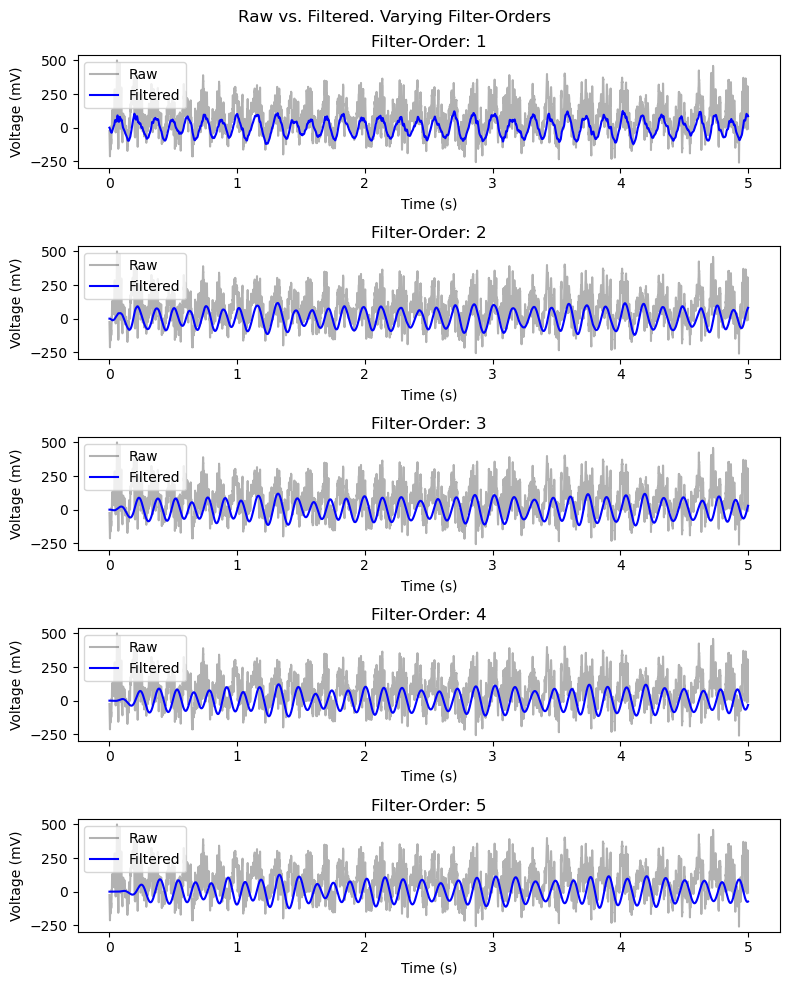

In [52]:
## Exercise 1.4
# fiddle with the filter order
##

from scipy.signal import butter, sosfilt
import numpy as np
import matplotlib.pyplot as plt
# Here i chose the focus on filtering the theta signal from the lfp signal, because its most prominent, as given by the fft figure

filter_order = [1,2,3,4,5]

plt.figure(figsize=(8, 2*len(filter_order)))
for i, order in enumerate(filter_order, 1):
    sos = signal.butter(
    N = order,
    Wn = [4, 8],
    btype = 'bandpass',
    output= 'sos',
    fs = sampling_rate
    )

    # Apply the filter to the LFP
    filtered = sosfilt(sos, lfp_segment)

    # Plot
    plt.subplot(len(filter_order), 1, i)
    plt.plot(time, lfp_segment, color = 'black', alpha = 0.3, label = 'Raw')
    plt.plot(time, filtered, color = 'blue', label = 'Filtered')
    plt.title(f'Filter-Order: {order}')
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage (mV)')
    plt.legend()
    
plt.suptitle(f'Raw vs. Filtered. Varying Filter-Orders')
plt.tight_layout()
plt.show()

Exercise 1.4 comment: the lower the filter order, the less smooth the signal is at the extremes (maxima and minima of the waves). Artifacts such as these are usually introduced with a low order filter. the higher the order of the filter goes, there is less artifacts, already evident between filter order 1 and 2, where 2 already displays a smooth signal without oscialltions and the peaks (and troughs). However, with increasing filter order, more phase shift is introduced in teh signal, evident from the blue filtered signal seeming shifted to the right compared to the grey raw signal, which is most evident in the order 5 filtered signal, looking at the peaks of the filtered and raw signal.

In [50]:
## Exercise 1.5
# filter order timing
##

filter_order = [1,2,3,4,5]

for i, order in enumerate(filter_order, 1):
    sos = signal.butter(
    N = order,
    Wn = [4, 8],
    btype = 'bandpass',
    output= 'sos',
    fs = sampling_rate
    )
    
    %timeit signal.sosfilt(sos, lfp_segment)

111 μs ± 12.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
102 μs ± 2.71 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
107 μs ± 5.96 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
134 μs ± 30.8 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
122 μs ± 5.47 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


Exercise 1.5 comment: Continuing on the filter order, the higher the filter order is, the longer it takes to filter the data (in general). this is shown by the increase in %timeit signal.sosfilt output with increasing filter order i (although filter order 4 has a longer filter time than 5, in general the higher the order, the longer the filtering takes